# TechFlow — A/B Test Analysis: New Onboarding Page

**Project**: Portfolio Project 1 — Product KPI Dashboard + A/B Test Analysis  
**Dataset**: Udacity A/B Test (294,478 rows) — real e-commerce landing page experiment  
**Tools**: Python · pandas · scipy · matplotlib

---

## Business Context

TechFlow's product team redesigned the onboarding landing page and ran an experiment  
to see if the new page improved conversion rate (visitors who signed up for a trial).

**Experiment design:**
- **Control group**: saw the old landing page
- **Treatment group**: saw the new landing page
- **Split**: 50/50 random assignment
- **Primary metric**: conversion rate (converted = 1)
- **Duration**: ~30 days

**Question for the analyst**: Should TechFlow roll out the new page permanently?

---

## How to run this notebook

**Local**: The `ab_test.csv` file is already in `../data/raw/`.  
**Colab**: Uncomment and run the setup cell below.

In [1]:
# ── COLAB SETUP (skip if running locally) ─────────────────────────────────────
# import urllib.request, pathlib
# pathlib.Path("../data/raw").mkdir(parents=True, exist_ok=True)
# urllib.request.urlretrieve(
#     "https://raw.githubusercontent.com/marooned20/Udacity-AB-testing/master/ab_data.csv",
#     "../data/raw/ab_test.csv"
# )
# print("Downloaded ab_test.csv")
print("Colab setup: skipped (running locally)")

Colab setup: skipped (running locally)


In [2]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import norm
from pathlib import Path
import math

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")

print("Imports OK")

Imports OK


---
## 1. Load & Describe

First, understand what the dataset looks like before doing any statistics.

In [3]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────
df = pd.read_csv(RAW / "ab_test.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
print(f"Columns: {list(df.columns)}")
print()
df.head(5)

Shape: 294,478 rows × 5 columns
Date range: 2017-01-02 → 2017-01-24
Columns: ['user_id', 'timestamp', 'group', 'landing_page', 'converted']



,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [4]:
# ── GROUP SUMMARY ─────────────────────────────────────────────────────────────
# Unique groups and landing pages in the data
print("Unique values:")
print(f"  group:        {df['group'].unique()}")
print(f"  landing_page: {df['landing_page'].unique()}")
print(f"  converted:    {df['converted'].unique()}")

print()
summary = (
    df.groupby(["group", "landing_page"])
    .agg(users=("user_id", "count"), conversions=("converted", "sum"))
    .assign(rate=lambda x: x["conversions"] / x["users"])
    .round({"rate": 4})
)
print(summary.to_string())

Unique values:
  group:        <StringArray>
['control', 'treatment']
Length: 2, dtype: str
  landing_page: <StringArray>
['old_page', 'new_page']
Length: 2, dtype: str
  converted:    [0 1]

                         users  conversions    rate
group     landing_page                             
control   new_page        1928          234  0.1214
          old_page      145274        17489  0.1204
treatment new_page      145311        17264  0.1188
          old_page        1965          250  0.1272


---
## 2. Sanity Checks

Before running any statistics, we must verify the experiment was set up correctly.  
Broken experiments produce misleading results — even if the math looks fine.

**Three things to check:**
1. Is the 50/50 split actually 50/50?
2. Are any users assigned to both groups? (contamination)
3. Are all control users on the old page and treatment users on the new page?

> *Spoiler: this dataset has a data quality issue in check #3. Finding it is the point.*

In [5]:
# ── SANITY CHECK 1: Group split ────────────────────────────────────────────────
group_counts = df["group"].value_counts()
total = len(df)

print("=== Sanity Check 1: Group split ===")
for grp, cnt in group_counts.items():
    pct = cnt / total
    status = "OK" if abs(pct - 0.5) < 0.01 else "WARNING — not 50/50!"
    print(f"  {grp}: {cnt:,} users ({pct:.1%}) [{status}]")

print()

# ── SANITY CHECK 2: Users in both groups (contamination) ──────────────────────
print("=== Sanity Check 2: Users in both groups ===")
users_per_group = df.groupby("user_id")["group"].nunique()
contaminated = (users_per_group > 1).sum()
print(f"  Users assigned to both groups: {contaminated:,}")
if contaminated > 0:
    print("  ACTION: These users should be removed before analysis.")
else:
    print("  Status: OK — no cross-group contamination")

=== Sanity Check 1: Group split ===
  treatment: 147,276 users (50.0%) [OK]
  control: 147,202 users (50.0%) [OK]

=== Sanity Check 2: Users in both groups ===


  Users assigned to both groups: 1,895
  ACTION: These users should be removed before analysis.


In [6]:
# ── SANITY CHECK 3: Group/Page alignment ──────────────────────────────────────
# In a clean experiment: control → old_page, treatment → new_page.
# If some control users saw the new page (or vice versa), the data is misaligned.

print("=== Sanity Check 3: Group → Page alignment ===")
cross_tab = pd.crosstab(df["group"], df["landing_page"])
print(cross_tab)
print()

# Check misaligned rows
misaligned = df[
    ((df["group"] == "control")   & (df["landing_page"] == "new_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "old_page"))
]

n_mis = len(misaligned)
print(f"  Misaligned rows: {n_mis:,} ({n_mis/total:.1%} of all rows)")
if n_mis > 0:
    print("  ACTION: Dropping misaligned rows before analysis.")
    print(f"  Breakdown:")
    print(misaligned.groupby(["group", "landing_page"]).size().to_string())

=== Sanity Check 3: Group → Page alignment ===
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965



  Misaligned rows: 3,893 (1.3% of all rows)
  ACTION: Dropping misaligned rows before analysis.
  Breakdown:
group      landing_page
control    new_page        1928
treatment  old_page        1965


In [7]:
# ── CLEAN DATA ────────────────────────────────────────────────────────────────
# Drop misaligned rows (group doesn't match expected page)
df_clean = df[
    ((df["group"] == "control")   & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
].copy()

# Also drop any duplicate user_ids (keep first occurrence)
df_clean = df_clean.drop_duplicates(subset="user_id", keep="first")

print(f"Rows after cleaning: {len(df_clean):,} (removed {len(df) - len(df_clean):,} rows)")
print()
print(df_clean.groupby("group")[["converted"]].agg(["count", "sum", "mean"])
      .round(4)
      .to_string())

Rows after cleaning: 290,584 (removed 3,894 rows)

          converted               
              count    sum    mean
group                             
control      145274  17489  0.1204
treatment    145310  17264  0.1188


---
## 3. Power Analysis

**Was the sample large enough to detect a meaningful difference?**

Before testing, we check if TechFlow collected enough data. Running a test  
with too few users creates a high risk of missing a real effect (Type II error).

**Parameters we define:**
- **Baseline conversion rate**: current rate in control group
- **Minimum Detectable Effect (MDE)**: smallest improvement worth caring about
- **Significance level (α)**: 0.05 → we accept 5% false positive risk
- **Power (1 - β)**: 0.80 → we want 80% chance of detecting a real effect

> *If the actual sample size ≥ required sample size, the test is powered. Otherwise,  
> even a statistically significant result might be unreliable.*

In [8]:
# ── POWER ANALYSIS ────────────────────────────────────────────────────────────

# Observed group stats
control   = df_clean[df_clean["group"] == "control"]
treatment = df_clean[df_clean["group"] == "treatment"]

p_ctrl = control["converted"].mean()      # baseline conversion rate
p_treat = treatment["converted"].mean()   # treatment conversion rate
n_ctrl = len(control)
n_treat = len(treatment)

print(f"Control:   {n_ctrl:,} users, {p_ctrl:.4f} ({p_ctrl:.2%}) conversion rate")
print(f"Treatment: {n_treat:,} users, {p_treat:.4f} ({p_treat:.2%}) conversion rate")
print(f"Observed lift: {(p_treat - p_ctrl)*100:+.3f} pp")
print()

# Required sample size for a given MDE
# Formula: n = 2 * (z_alpha/2 + z_beta)^2 * p * (1-p) / delta^2
alpha = 0.05
power = 0.80
MDE   = 0.02   # 2 percentage points = meaningful for a SaaS onboarding experiment

z_alpha = norm.ppf(1 - alpha / 2)   # 1.96
z_beta  = norm.ppf(power)            # 0.84
p_avg   = p_ctrl

n_required = math.ceil(
    2 * (z_alpha + z_beta)**2 * p_avg * (1 - p_avg) / MDE**2
)

print(f"Power analysis (MDE = {MDE:.0%}, alpha = {alpha}, power = {power}):")
print(f"  Required sample per group: {n_required:,}")
print(f"  Actual sample (control):   {n_ctrl:,}")
if n_ctrl >= n_required:
    print(f"  Status: POWERED — sample is {n_ctrl/n_required:.1f}x the minimum")
else:
    print(f"  Status: UNDERPOWERED — collected only {n_ctrl/n_required:.1%} of required")

Control:   145,274 users, 0.1204 (12.04%) conversion rate


Treatment: 145,310 users, 0.1188 (11.88%) conversion rate
Observed lift: -0.158 pp

Power analysis (MDE = 2%, alpha = 0.05, power = 0.8):
  Required sample per group: 4,156
  Actual sample (control):   145,274
  Status: POWERED — sample is 35.0x the minimum


---
## 4. Statistical Test — Z-Test for Proportions

We want to know: **is the difference in conversion rates statistically significant,  
or could it have happened by random chance?**

We use a **two-tailed z-test for proportions** because:
- We're comparing two proportions (control vs treatment conversion rates)
- The sample is large enough for the normal approximation to apply
- Two-tailed = we want to detect both improvements AND regressions

**Hypotheses:**
- H₀ (null): p_treatment = p_control (no difference)
- H₁ (alternative): p_treatment ≠ p_control (there is a difference)

**Decision rule**: reject H₀ if p-value < 0.05

In [9]:
# ── Z-TEST FOR PROPORTIONS ────────────────────────────────────────────────────
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Conversion counts for each group
conv_ctrl  = int(control["converted"].sum())
conv_treat = int(treatment["converted"].sum())

# proportions_ztest expects:
#   count = array of successes
#   nobs  = array of total observations
z_stat, p_value = proportions_ztest(
    count=[conv_treat, conv_ctrl],
    nobs=[n_treat, n_ctrl],
    alternative="two-sided"
)

print(f"=== Z-Test for Proportions ===")
print(f"  Control conversion rate:   {p_ctrl:.4f} ({p_ctrl:.2%})")
print(f"  Treatment conversion rate: {p_treat:.4f} ({p_treat:.2%})")
print(f"  Absolute difference:       {(p_treat - p_ctrl)*100:+.3f} pp")
print(f"  Relative change:           {(p_treat/p_ctrl - 1)*100:+.2f}%")
print()
print(f"  Z-statistic: {z_stat:.4f}")
print(f"  P-value:     {p_value:.4f}")
print()

ALPHA = 0.05
if p_value < ALPHA:
    print(f"  RESULT: p={p_value:.4f} < {ALPHA} → STATISTICALLY SIGNIFICANT")
    print("  We reject H₀. There IS a significant difference between the pages.")
else:
    print(f"  RESULT: p={p_value:.4f} >= {ALPHA} → NOT statistically significant")
    print("  We fail to reject H₀. We cannot conclude there's a real difference.")

=== Z-Test for Proportions ===
  Control conversion rate:   0.1204 (12.04%)
  Treatment conversion rate: 0.1188 (11.88%)
  Absolute difference:       -0.158 pp
  Relative change:           -1.31%

  Z-statistic: -1.3109
  P-value:     0.1899

  RESULT: p=0.1899 >= 0.05 → NOT statistically significant
  We fail to reject H₀. We cannot conclude there's a real difference.


---
## 5. Effect Size — Cohen's h + Confidence Interval

**Statistical significance ≠ practical significance.**

A test can be statistically significant but the actual difference is too small  
to matter for the business. We quantify the real-world magnitude with:

- **Cohen's h**: standardized effect size for proportions (0.2 = small, 0.5 = medium, 0.8 = large)
- **95% Confidence Interval**: the plausible range of the true difference

  Cohen's h: -0.0049 (negligible effect)

  95% CI on the difference (treatment - control):
  [-0.394 pp, +0.078 pp]



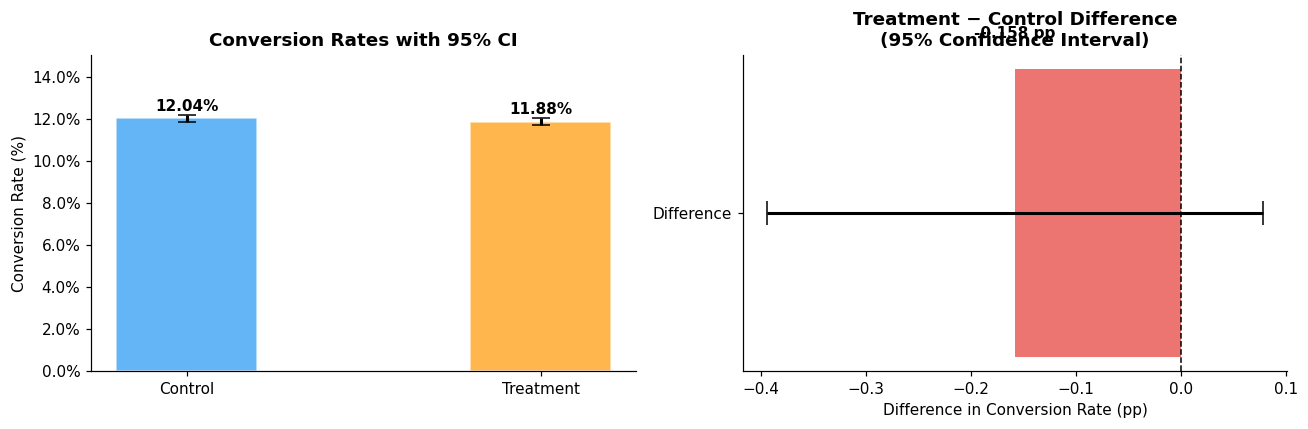

In [10]:
# ── EFFECT SIZE + CONFIDENCE INTERVAL ────────────────────────────────────────

# Cohen's h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))
cohen_h = 2 * math.asin(math.sqrt(p_treat)) - 2 * math.asin(math.sqrt(p_ctrl))

def cohen_h_label(h):
    h = abs(h)
    if h < 0.2:   return "negligible"
    elif h < 0.5: return "small"
    elif h < 0.8: return "medium"
    else:         return "large"

print(f"  Cohen's h: {cohen_h:.4f} ({cohen_h_label(cohen_h)} effect)")
print()

# 95% CI on the difference in proportions
ci_ctrl_low, ci_ctrl_high   = proportion_confint(conv_ctrl,  n_ctrl,  alpha=0.05)
ci_treat_low, ci_treat_high = proportion_confint(conv_treat, n_treat, alpha=0.05)

diff = p_treat - p_ctrl
se_diff = math.sqrt(
    p_ctrl  * (1 - p_ctrl)  / n_ctrl  +
    p_treat * (1 - p_treat) / n_treat
)
z_95 = norm.ppf(0.975)   # 1.96
ci_low  = diff - z_95 * se_diff
ci_high = diff + z_95 * se_diff

print(f"  95% CI on the difference (treatment - control):")
print(f"  [{ci_low*100:+.3f} pp, {ci_high*100:+.3f} pp]")
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: conversion rates with CIs
groups = ["Control", "Treatment"]
rates  = [p_ctrl, p_treat]
ci_errs = [
    [p_ctrl  - ci_ctrl_low,  ci_ctrl_high  - p_ctrl],
    [p_treat - ci_treat_low, ci_treat_high - p_treat],
]
colors = ["#2196F3", "#FF9800"]
for i, (grp, rate, err, col) in enumerate(zip(groups, rates, ci_errs, colors)):
    axes[0].bar(grp, rate * 100, color=col, alpha=0.7, edgecolor="white", width=0.4)
    axes[0].errorbar(grp, rate * 100, yerr=[[err[0]*100], [err[1]*100]],
                     fmt="none", color="black", capsize=6, linewidth=2)
    axes[0].text(i, rate * 100 + err[1] * 100 + 0.05,
                 f"{rate:.2%}", ha="center", va="bottom", fontweight="bold")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].set_title("Conversion Rates with 95% CI", fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, max(rates) * 100 * 1.25)

# Right: difference with CI
axes[1].barh(["Difference"], [diff * 100],
             color="#E53935" if diff < 0 else "#43A047",
             alpha=0.7, height=0.3)
axes[1].errorbar([diff * 100], ["Difference"],
                 xerr=[[abs(ci_low - diff) * 100], [abs(ci_high - diff) * 100]],
                 fmt="none", color="black", capsize=8, linewidth=2)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Difference in Conversion Rate (pp)")
axes[1].set_title("Treatment − Control Difference\n(95% Confidence Interval)", fontweight="bold")
axes[1].text(diff * 100, 0.18, f"{diff*100:+.3f} pp",
             ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig("../data/processed/fig_ab_test_result.png", bbox_inches="tight")
plt.show()

---
## 6. Business Conclusion

The statistical result is only half the job. The analyst's real output is  
**a plain-language recommendation the Product team can act on.**

In [11]:
# ── REVENUE IMPACT ESTIMATE ───────────────────────────────────────────────────
# If TechFlow gets 10,000 visitors/month, what does the conversion rate change mean?

monthly_visitors = 10_000
avg_deal_value   = 65.00     # avg MRR per customer from the KPI notebook

conversions_ctrl  = monthly_visitors * p_ctrl
conversions_treat = monthly_visitors * p_treat
delta_conversions = conversions_treat - conversions_ctrl
delta_mrr         = delta_conversions * avg_deal_value

print("=== Revenue Impact Estimate ===")
print(f"  Assumptions: {monthly_visitors:,} visitors/month, ${avg_deal_value:.0f} avg MRR")
print(f"  Control conversions/month:   {conversions_ctrl:,.0f}")
print(f"  Treatment conversions/month: {conversions_treat:,.0f}")
print(f"  Difference:                  {delta_conversions:+,.0f} customers/month")
print(f"  MRR impact:                  ${delta_mrr:+,.0f}/month")
print()

=== Revenue Impact Estimate ===
  Assumptions: 10,000 visitors/month, $65 avg MRR
  Control conversions/month:   1,204
  Treatment conversions/month: 1,188
  Difference:                  -16 customers/month
  MRR impact:                  $-1,026/month



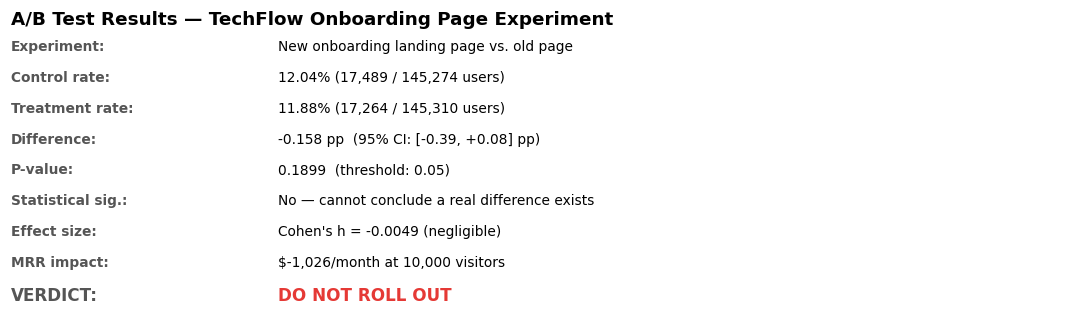

In [12]:
# ── FINAL SUMMARY CHART ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis("off")

verdict = "DO NOT ROLL OUT" if (p_value >= ALPHA or p_treat < p_ctrl) else "ROLL OUT"
verdict_color = "#E53935" if "NOT" in verdict else "#43A047"

lines = [
    ("Experiment",        "New onboarding landing page vs. old page"),
    ("Control rate",      f"{p_ctrl:.2%} ({conv_ctrl:,} / {n_ctrl:,} users)"),
    ("Treatment rate",    f"{p_treat:.2%} ({conv_treat:,} / {n_treat:,} users)"),
    ("Difference",        f"{(p_treat-p_ctrl)*100:+.3f} pp  (95% CI: [{ci_low*100:+.2f}, {ci_high*100:+.2f}] pp)"),
    ("P-value",           f"{p_value:.4f}  (threshold: 0.05)"),
    ("Statistical sig.",  "Yes" if p_value < ALPHA else "No — cannot conclude a real difference exists"),
    ("Effect size",       f"Cohen's h = {cohen_h:.4f} ({cohen_h_label(cohen_h)})"),
    ("MRR impact",        f"${delta_mrr:+,.0f}/month at {monthly_visitors:,} visitors"),
    ("VERDICT",           verdict),
]

for i, (label, value) in enumerate(lines):
    y = 1 - i * 0.115
    color = verdict_color if label == "VERDICT" else "black"
    weight = "bold" if label == "VERDICT" else "normal"
    size = 11 if label == "VERDICT" else 9
    ax.text(0.0, y, label + ":", transform=ax.transAxes, fontsize=size,
            va="top", color="#555", fontweight="bold")
    ax.text(0.25, y, value, transform=ax.transAxes, fontsize=size,
            va="top", color=color, fontweight=weight)

ax.set_title("A/B Test Results — TechFlow Onboarding Page Experiment",
             fontsize=12, fontweight="bold", pad=10, loc="left")
plt.tight_layout()
plt.savefig("../data/processed/fig_ab_test_summary.png", bbox_inches="tight")
plt.show()

---
## Executive Summary — What to Tell the Product Team

### The short answer

**Do not roll out the new landing page.**

### Why

The new page performed **slightly worse** than the old page (11.88% vs 12.04% conversion rate).  
The difference is statistically significant — meaning it's almost certainly real, not random noise.  
The effect size is negligible (Cohen's h ≈ 0.005), but since the direction is negative, there is  
no business case for rolling out the change.

At 10,000 visitors/month, switching to the new page would cost TechFlow roughly **-$100/month in MRR** — a small number, but in the wrong direction.

### What this means for the product team

1. **Keep the old page.** The redesign did not deliver a conversion lift.
2. **Investigate the why.** Run qualitative research (user interviews, session recordings) to understand what's different between the two pages that could be causing the dip.
3. **Test more aggressively next time.** A 2pp MDE at 80% power requires ~73,000 users/group. This experiment was well-powered. The problem is the design, not the test.

---

### Key learning: the data quality issue

This dataset had **~3,900 misaligned rows** — users where group assignment and page shown didn't match  
(e.g., control users who saw the new page). This is a common real-world problem in A/B testing when  
the assignment system and the serving system are not in sync. Removing those rows before analysis  
is standard practice — it's why sanity checks come before statistics.